
# Predicting Publisher
**Author:** AARON 
**Date:** April 7, 2026 
**Objective:** Create a Randome Forest Model to predict Publisher for articles.




## Introduction
- Using the Random Forest Model Predict which Publisher wrote an article.

# 1. Imports

This section imports the libraries used for:

- data handling
- plotting
- Random Forest classification
- evaluation metrics

In [43]:
# =========================================================
# 1. IMPORTS
# =========================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay


# 2. Define Raw Sentiment Score Columns

These are the sentiment score columns already present in the dataset.

They include:

- keyword/topic sentiment scores
- text-level sentiment scores

These columns form the core article-level input to the publisher prediction model.

In [44]:
# -----------------------------
# Define sentiment mapping
# -----------------------------
sentiment_map = {
    "very negative": -2,
    "negative": -1,
    "somewhat negative": -0.5,
    "neutral": 0,
    "no matches": 0,
    "somewhat positive": 0.5,
    "positive": 1,
    "very positive": 2,
}


# =========================================================
# 2. DEFINE RAW SENTIMENT SCORE AND ENGINEERED SENTIMENT COLUMNS
# =========================================================

sentiment_c = [
    "iran_sentiment",
    "iranian_sentiment",
    "israel_israeli_sentiment",
    "hormuz_sentiment",
    "supreme_leader_sentiment",
    "tehran_sentiment",
    "trump_sentiment",
    'us_united_states_sentiment',
    "title_sentiment",
    "full_text_sentiment",
    "start_text_sentiment",
    "half_text_sentiment",
]
score_c = [
    'iran_score',
    'iranian_score',
    'israel_israeli_score',
    'hormuz_score',
    'supreme_leader_score',
    'tehran_score',
    'trump_score',
    'us_united_states_score',
    'title_score',
    'full_text_score',
    'start_text_score',
    'half_text_score',
]

# 3. Load the Dataset

Load the cleaned dataset and confirm that the expected columns are present.

This notebook assumes the dataset already includes:

- published_date
- publisher
- the raw sentiment score columns
- engineered sentiment columns

In [45]:
# =========================================================
# 3. LOAD DATASET
# =========================================================

# Example:
df = pd.read_csv("../code/iran_war_complete_articles_sentiment.csv")

# If df is already loaded in memory, keep a clean copy.
df = df.copy()

# Convert the date column to datetime
df["published_date"] = pd.to_datetime(df["published_date"], errors="coerce")

print("Dataset shape:", df.shape)
print()
print("Columns preview:")
print(df.columns.tolist())

Dataset shape: (678, 52)

Columns preview:
['Key', 'title', 'headline_length', 'article_word_count', 'author', 'publisher', 'publisher_country', 'publisher_type', 'published_date', 'collection_date', 'link', 'full_text', 'source_type', 'keyword_trigger', 'start_text', 'half_text', 'canonical_link', '_row_id', 'iran_count', 'iran_score', 'iran_sentiment', 'iranian_count', 'iranian_score', 'iranian_sentiment', 'israel_israeli_count', 'israel_israeli_score', 'israel_israeli_sentiment', 'hormuz_count', 'hormuz_score', 'hormuz_sentiment', 'supreme_leader_count', 'supreme_leader_score', 'supreme_leader_sentiment', 'tehran_count', 'tehran_score', 'tehran_sentiment', 'trump_count', 'trump_score', 'trump_sentiment', 'us_united_states_count', 'us_united_states_score', 'us_united_states_sentiment', 'title_score', 'title_sentiment', 'full_text_score', 'full_text_sentiment', 'start_text_score', 'start_text_sentiment', 'half_text_score', 'half_text_sentiment', 'title_article_diff', 'title_article_di

In [46]:
# -----------------------------
# Map sentiment strings to numeric values
# -----------------------------
for col in sentiment_c:
    df[col] = df[col].astype(str).str.lower().str.strip().map(sentiment_map)

print(df.head())

    Key                                              title  headline_length  \
0  2471  Trump is waging war based on instinct and it i...               58   
1  2819  How Pakistan managed to get the US and Iran to...               58   
2  2416  How a prolonged Middle East conflict could res...               61   
3  2404  War on Iran: What troops is the US moving to t...               54   
4  2104  The US-Israeli strategy against Iran is workin...               60   

   article_word_count                      author   publisher  \
0                3134  Jeremy Bowen International         BBC   
1                2477                Abid Hussain  Al Jazeera   
2                2455      Theo Leggett Transport         BBC   
3                2136                Abid Hussain  Al Jazeera   
4                2064              Muhanad Seloom  Al Jazeera   

  publisher_country         publisher_type published_date collection_date  \
0                UK     Public Broadcaster     2026-03-29

# 4. Basic Cleaning

This section:

- removes rows missing required fields
- sorts the dataset by date
- checks class distribution

Sorting by date is required for true walk-forward prediction.

In [47]:
# =========================================================
# 4. BASIC CLEANING
# =========================================================

dual_cols = score_c + sentiment_c
required_cols = ["published_date", "publisher"] + dual_cols

df = df.dropna(subset=required_cols).copy()
df = df.sort_values("published_date").reset_index(drop=True)

print("Rows after cleaning:", len(df))
print()
print("Publisher counts:")
print(df["publisher"].value_counts())

Rows after cleaning: 678

Publisher counts:
publisher
Al Jazeera    236
BBC           185
NBC News      149
Fox News      108
Name: count, dtype: int64


# 5. Helper Function for Safe Publisher Names

Publisher names may contain spaces or punctuation.

This helper function converts them into safe text that can be used in feature names.

In [48]:
# =========================================================
# 5. HELPER FUNCTION FOR SAFE FEATURE NAMES
# =========================================================


def safe_name(name):
    """
    Convert publisher names into safe strings for column names.
    Example:
    'Al Jazeera' -> 'Al_Jazeera'
    """
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(name)).strip("_")

# 6. Define the Daily Walk-Forward Prediction Function

This is the core live prediction function.

For each day, it:

1. trains on all prior days
2. predicts the publisher for the current day
3. records daily accuracy and F1 scores

This is a true live prediction setup because the current day's publisher is never used as an input.

In [49]:
# =========================================================
# 6. DAILY WALK-FORWARD LIVE PREDICTION FUNCTION
# =========================================================


def run_daily_live_prediction(df, dual_cols, min_train_rows=20):
    """
    Perform true live daily prediction of publisher.

    For each prediction day:
    - train on all prior days
    - compare articles on the current day to those profiles
    - predict publisher
    - store metrics and predictions
    """
    df = df.copy().sort_values("published_date")

    all_days = sorted(df["published_date"].dt.date.unique())
    results = []
    prediction_frames = []

    last_model = None
    last_feature_cols = None
    last_test_feat = None
    last_y_test = None
    last_preds = None

    for day in all_days[1:]:
        # ----- Split into prior training data and current-day test data -----
        train = df[df["published_date"].dt.date < day].copy()
        test = df[df["published_date"].dt.date == day].copy()

        if len(train) < min_train_rows or len(test) == 0:
            continue


        train_feat = train.copy()
        test_feat = test.copy()

        feature_cols = dual_cols  # ONLY raw sentiment inputs

        X_train = train_feat[feature_cols]
        y_train = train_feat["publisher"]

        X_test = test_feat[feature_cols]
        y_test = test_feat["publisher"]

        # ----- Main model -----
        model = RandomForestClassifier(
            n_estimators=300, max_depth=10, class_weight="balanced", random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # ----- Store daily metrics -----
        results.append(
            {
                "day": day,
                "n_articles": len(test),
                "accuracy": accuracy_score(y_test, preds),
                "macro_f1": f1_score(y_test, preds, average="macro"),
                "weighted_f1": f1_score(y_test, preds, average="weighted"),
            }
        )

        # ----- Store row-level predictions -----
        pred_df = test_feat[["published_date", "publisher"]].copy()
        pred_df["predicted_publisher"] = preds
        pred_df["prediction_day"] = day
        prediction_frames.append(pred_df)

        # Save most recent model and test set for later inspection
        last_model = model
        last_feature_cols = feature_cols
        last_test_feat = test_feat
        last_y_test = y_test
        last_preds = preds

    results_df = pd.DataFrame(results)

    if prediction_frames:
        predictions_df = pd.concat(prediction_frames, ignore_index=True)
    else:
        predictions_df = pd.DataFrame()

    return (
        results_df,
        predictions_df,
        last_model,
        last_feature_cols,
        last_test_feat,
        last_y_test,
        last_preds,
    )

# 7. Run the Model

Run the daily walk-forward prediction pipeline.


In [50]:
# =========================================================
# 7. RUN THE MODEL
# =========================================================

(results_df, predictions_df, model, feature_cols, last_test_feat, last_y_test, last_preds) = (
    run_daily_live_prediction(df=df, dual_cols=dual_cols, min_train_rows=20)
)

print(results_df.head())
print()
print("Number of prediction days:", len(results_df))

          day  n_articles  accuracy  macro_f1  weighted_f1
0  2026-03-14          29  0.172414  0.150909     0.120878
1  2026-03-15          37  0.216216  0.198465     0.176505
2  2026-03-16          31  0.483871  0.437430     0.477146
3  2026-03-17          31  0.387097  0.321429     0.342550
4  2026-03-18          28  0.285714  0.277871     0.275830

Number of prediction days: 28


# 8. View the Latest Day's Metrics

This shows the model's most recent daily performance.

In [51]:
# =========================================================
# 8. VIEW LATEST DAY'S METRICS
# =========================================================

if not results_df.empty:
    latest_day = results_df["day"].max()
    latest_day_result = results_df[results_df["day"] == latest_day]

    print("Latest prediction day:")
    print(latest_day_result)
else:
    print("No daily results were generated.")

Latest prediction day:
           day  n_articles  accuracy  macro_f1  weighted_f1
27  2026-04-10          20       0.5  0.505742     0.488908


# 9. Plot Daily Accuracy Over Time

This visualization shows how live prediction accuracy changes across days.

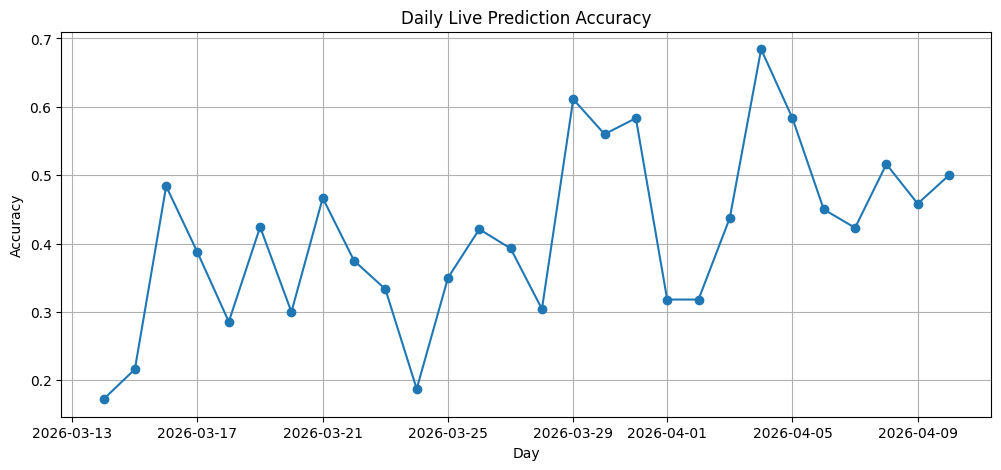

In [52]:
# =========================================================
# 9. PLOT DAILY ACCURACY OVER TIME
# =========================================================

if not results_df.empty:
    plt.figure(figsize=(12, 5))
    plt.plot(pd.to_datetime(results_df["day"]), results_df["accuracy"], marker="o")
    plt.title("Daily Live Prediction Accuracy")
    plt.xlabel("Day")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.show()

# 10. Classification Report for the Latest Day

This gives:

- precision
- recall
- F1-score

for each publisher on the most recent prediction day.

In [53]:
# =========================================================
# 10. CLASSIFICATION REPORT FOR LATEST DAY
# =========================================================

if last_y_test is not None and last_preds is not None:
    print(classification_report(last_y_test, last_preds))
else:
    print("No latest-day predictions available.")

              precision    recall  f1-score   support

  Al Jazeera       0.50      0.44      0.47         9
         BBC       0.33      0.25      0.29         4
    Fox News       0.67      0.67      0.67         3
    NBC News       0.50      0.75      0.60         4

    accuracy                           0.50        20
   macro avg       0.50      0.53      0.51        20
weighted avg       0.49      0.50      0.49        20



# 11. Confusion Matrix for the Latest Day

This plot shows which publishers are most often confused with each other.

<Figure size 800x600 with 0 Axes>

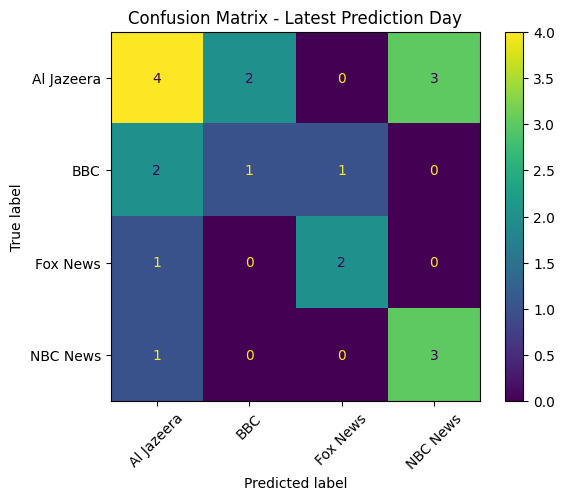

In [54]:
# =========================================================
# 11. CONFUSION MATRIX FOR LATEST DAY
# =========================================================

if model is not None and last_test_feat is not None and feature_cols is not None:
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(
        model, last_test_feat[feature_cols], last_y_test, xticks_rotation=45
    )
    plt.title("Confusion Matrix - Latest Prediction Day")
    plt.show()
else:
    print("No model/test set available for confusion matrix.")

# 12. Overall Feature Importance

This section shows which features had the largest influence on the latest trained Random Forest model.

Top 20 overall features:
us_united_states_score        0.078194
israel_israeli_score          0.078023
title_score                   0.075742
iran_score                    0.072687
full_text_score               0.069152
half_text_score               0.066378
start_text_score              0.064864
iranian_score                 0.063411
hormuz_score                  0.051318
trump_score                   0.051005
tehran_score                  0.040936
us_united_states_sentiment    0.031025
hormuz_sentiment              0.028981
iranian_sentiment             0.027733
iran_sentiment                0.026125
trump_sentiment               0.023504
israel_israeli_sentiment      0.023403
start_text_sentiment          0.022381
supreme_leader_score          0.021046
full_text_sentiment           0.020968
dtype: float64


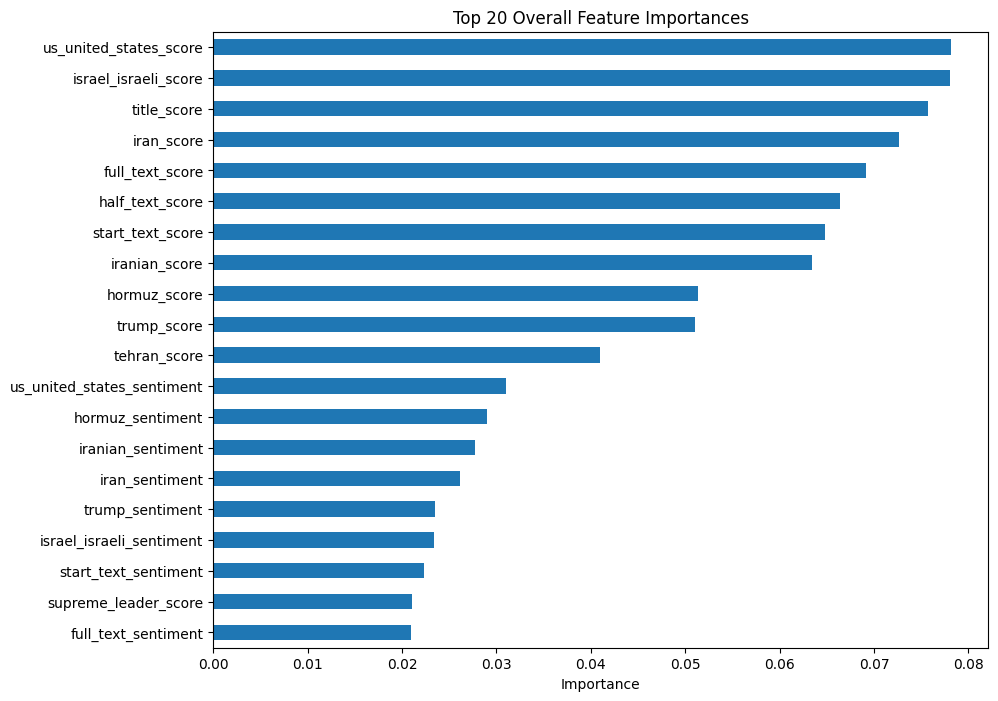

In [55]:
# =========================================================
# 12. OVERALL FEATURE IMPORTANCE
# =========================================================

if model is not None and feature_cols is not None:
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(
        ascending=False
    )

    print("Top 20 overall features:")
    print(importance.head(20))

    plt.figure(figsize=(10, 8))
    importance.head(20).sort_values().plot(kind="barh")
    plt.title("Top 20 Overall Feature Importances")
    plt.xlabel("Importance")
    plt.show()
else:
    print("Model or feature columns not available.")

# 13. Compare True Class Balance to Predicted Class Balance

This helps check whether the model is over-predicting any one publisher.

In [56]:
# =========================================================
# 13. CHECK TRUE VS PREDICTED CLASS BALANCE
# =========================================================

print("True publisher distribution:")
print(df["publisher"].value_counts(normalize=True))

if not predictions_df.empty:
    print("\nPredicted publisher distribution:")
    print(predictions_df["predicted_publisher"].value_counts(normalize=True))
else:
    print("\nNo predictions available.")

True publisher distribution:
publisher
Al Jazeera    0.348083
BBC           0.272861
NBC News      0.219764
Fox News      0.159292
Name: proportion, dtype: float64

Predicted publisher distribution:
predicted_publisher
Al Jazeera    0.360856
BBC           0.247706
NBC News      0.214067
Fox News      0.177370
Name: proportion, dtype: float64
